# Sales Dashboard Analysis

This project analyzes retail sales data from the Superstore dataset to uncover patterns in sales, profit, customer value, and product performance.

The goal is to answer practical business questions and turn raw sales data into insights that support decision making.

## Business Questions

This analysis focuses on five main questions:

1. Which region generates the most sales?
2. Which product categories drive the most revenue and profit?
3. How do sales change over time?
4. Who are the top customers by sales?
5. Which sub categories perform well in both sales and profit?

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import FuncFormatter

sns.set_theme(style="whitegrid", context="talk")

plt.rcParams["figure.figsize"] = (12, 7)
plt.rcParams["axes.titlesize"] = 20
plt.rcParams["axes.labelsize"] = 14
plt.rcParams["xtick.labelsize"] = 11
plt.rcParams["ytick.labelsize"] = 11
plt.rcParams["legend.fontsize"] = 11
plt.rcParams["figure.facecolor"] = "white"
plt.rcParams["axes.facecolor"] = "#f8f9fa"
plt.rcParams["axes.edgecolor"] = "#dddddd"
plt.rcParams["grid.color"] = "#d9d9d9"
plt.rcParams["grid.linestyle"] = ":"
plt.rcParams["grid.alpha"] = 0.7

df = pd.read_csv("data/Superstore.csv", encoding="latin1")
df["Order Date"] = pd.to_datetime(df["Order Date"], errors="coerce")
df = df.dropna(subset=["Order Date"])

## Data Overview

The dataset contains retail order level data including order date, region, category, sub category, customer information, sales, and profit.

This makes it useful for exploring revenue performance, profitability, customer concentration, and product trends.

In [2]:
print("Rows:", len(df))
print("Columns:", len(df.columns))
print("\nColumn Names:")
print(df.columns.tolist())

df.head()

Rows: 9994
Columns: 21

Column Names:
['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State', 'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit']


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,2016-11-08,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,2016-11-08,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,2016-06-12,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,2015-10-11,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,2015-10-11,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


## Data Cleaning

Before analysis, the dataset was checked for formatting issues.

Main preparation steps:
- converted the order date column to datetime
- removed rows with invalid order dates
- confirmed the main sales and profit fields were available for analysis

In [3]:
df["Order Date"] = pd.to_datetime(df["Order Date"], errors="coerce")
df = df.dropna(subset=["Order Date"])

print("Missing values:")
print(df.isnull().sum())

Missing values:
Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64


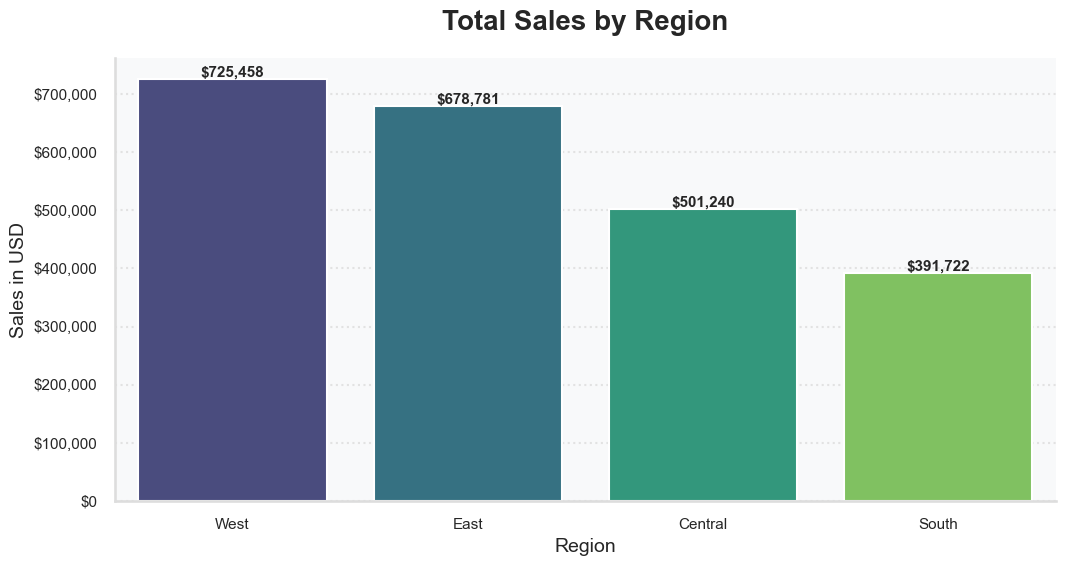

In [4]:
sales_by_region = (
    df.groupby("Region")["Sales"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

plt.figure(figsize=(11, 6))
ax = sns.barplot(
    data=sales_by_region,
    x="Region",
    y="Sales",
    hue="Region",
    palette="viridis",
    legend=False
)

ax.set_title("Total Sales by Region", pad=20, weight="bold")
ax.set_xlabel("Region")
ax.set_ylabel("Sales in USD")

ax.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f"${x:,.0f}"))

for i, value in enumerate(sales_by_region["Sales"]):
    ax.text(i, value + 5000, f"${value:,.0f}", ha="center", weight="bold", fontsize=11)

sns.despine()
plt.tight_layout()
plt.show()

### Insight

The West region generates the highest total sales in the dataset, indicating that it is the strongest performing geographic market.

This suggests the business likely has stronger demand, better distribution coverage, or a more valuable customer base in that region compared with the others.

The South region produces the lowest total sales, which may indicate weaker demand or lower market penetration.

From a business perspective, leadership should analyze what is driving success in the West region and determine whether those strategies can be replicated in weaker regions such as the South.

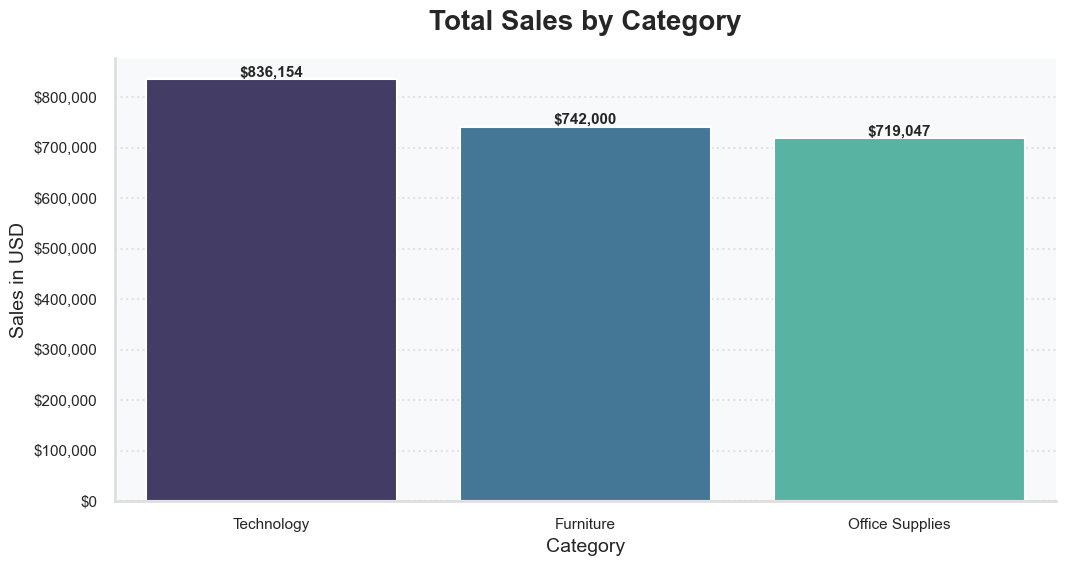

In [5]:
sales_by_category = (
    df.groupby("Category")["Sales"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

plt.figure(figsize=(11, 6))
ax = sns.barplot(
    data=sales_by_category,
    x="Category",
    y="Sales",
    hue="Category",
    palette="mako",
    legend=False
)

ax.set_title("Total Sales by Category", pad=20, weight="bold")
ax.set_xlabel("Category")
ax.set_ylabel("Sales in USD")

ax.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f"${x:,.0f}"))

for i, value in enumerate(sales_by_category["Sales"]):
    ax.text(i, value + 5000, f"${value:,.0f}", ha="center", weight="bold", fontsize=11)

sns.despine()
plt.tight_layout()
plt.show()

### Insight

Technology is the highest revenue generating product category in the dataset, outperforming both Furniture and Office Supplies.

This indicates that technology related products are a major driver of the company's sales performance.

Furniture generates strong revenue but does not lead overall sales, suggesting that although it contributes significantly to revenue, it may not be the primary growth driver.

Office Supplies contributes steady sales but at a lower total value compared with Technology.

The company should continue prioritizing high demand technology products while evaluating whether there are opportunities to increase revenue in other categories through product mix adjustments or targeted promotions.

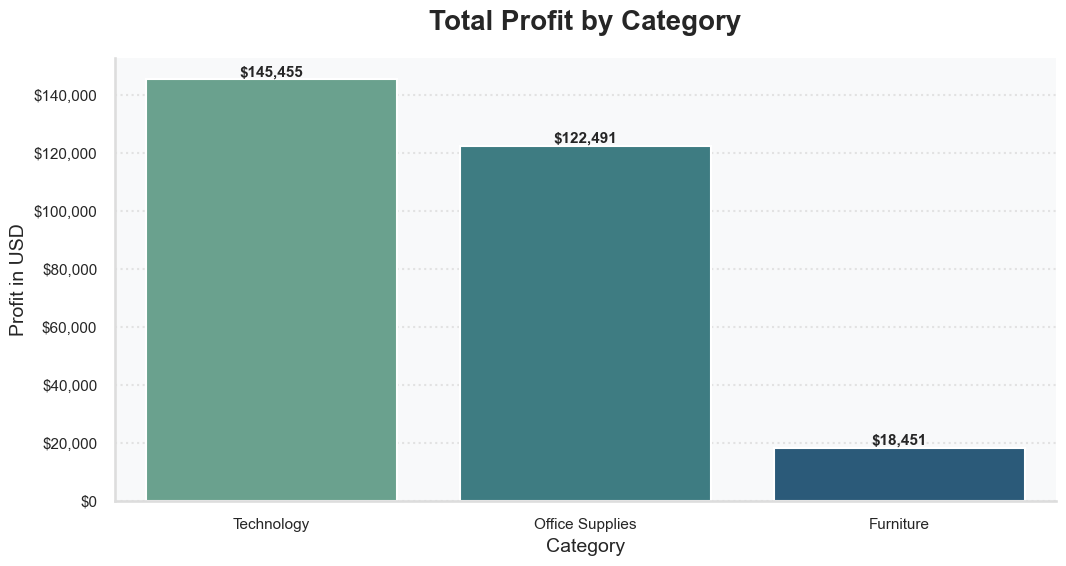

In [6]:
profit_by_category = (
    df.groupby("Category")["Profit"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

plt.figure(figsize=(11, 6))
ax = sns.barplot(
    data=profit_by_category,
    x="Category",
    y="Profit",
    hue="Category",
    palette="crest",
    legend=False
)

ax.set_title("Total Profit by Category", pad=20, weight="bold")
ax.set_xlabel("Category")
ax.set_ylabel("Profit in USD")

ax.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f"${x:,.0f}"))

for i, value in enumerate(profit_by_category["Profit"]):
    ax.text(i, value + 1000, f"${value:,.0f}", ha="center", weight="bold", fontsize=11)

sns.despine()
plt.tight_layout()
plt.show()

### Insight

Technology generates the highest overall profit among the product categories, confirming that it is not only the strongest revenue driver but also the most profitable segment.

Office Supplies also contributes a meaningful amount of profit despite generating lower total sales than Technology, which suggests it may have healthier profit margins.

Furniture generates significant sales but comparatively weaker profit, indicating that costs, discounting, or shipping expenses may be reducing its profitability.

This suggests that management should review pricing strategies, cost structures, and logistics for furniture products to improve profit margins.

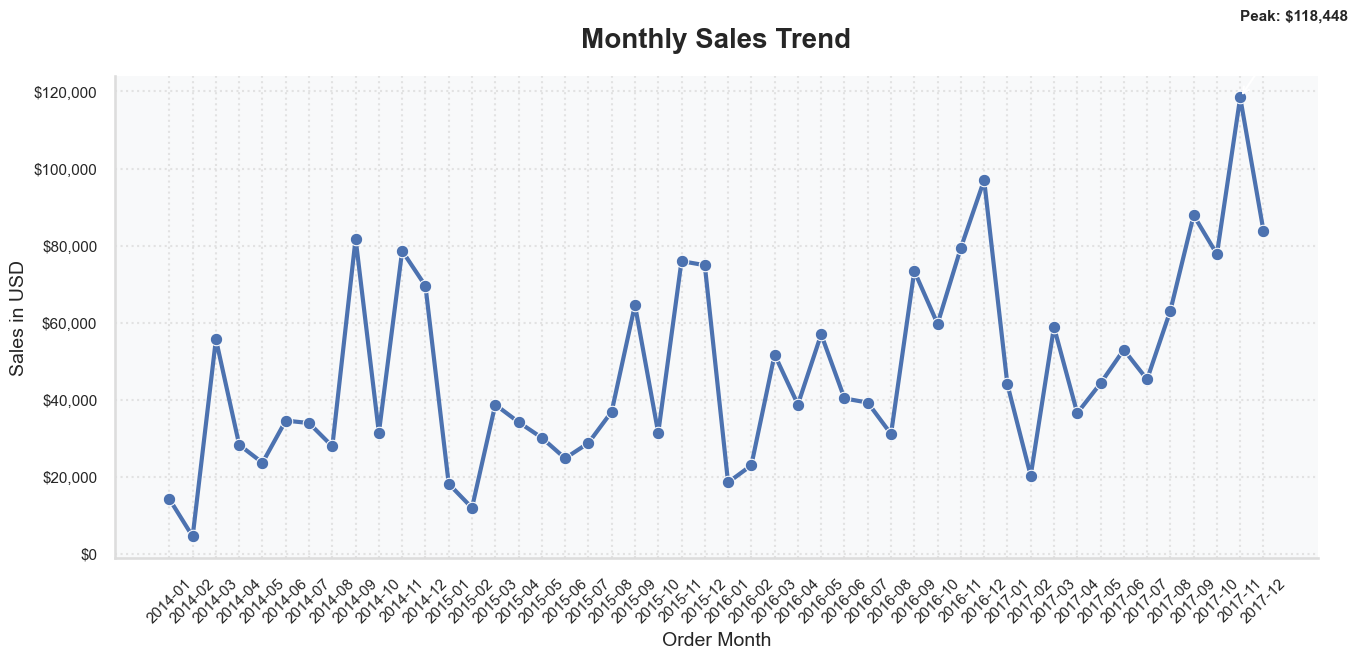

In [7]:
df["Order Month"] = df["Order Date"].dt.to_period("M").astype(str)

monthly_sales = (
    df.groupby("Order Month")["Sales"]
    .sum()
    .reset_index()
)

plt.figure(figsize=(14, 7))
ax = sns.lineplot(
    data=monthly_sales,
    x="Order Month",
    y="Sales",
    marker="o",
    linewidth=3
)

ax.set_title("Monthly Sales Trend", pad=20, weight="bold")
ax.set_xlabel("Order Month")
ax.set_ylabel("Sales in USD")

ax.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f"${x:,.0f}"))
plt.xticks(rotation=45)

max_idx = monthly_sales["Sales"].idxmax()
max_month = monthly_sales.loc[max_idx, "Order Month"]
max_value = monthly_sales.loc[max_idx, "Sales"]

ax.annotate(
    f"Peak: ${max_value:,.0f}",
    xy=(max_idx, max_value),
    xytext=(max_idx, max_value + 20000),
    arrowprops=dict(arrowstyle="->", lw=1.5),
    fontsize=11,
    weight="bold"
)

sns.despine()
plt.tight_layout()
plt.show()

### Insight

Sales fluctuate noticeably over time, with clear peaks in certain months and slower performance in others.

The strongest sales month in the dataset represents the peak period of demand, suggesting seasonal effects or the impact of promotional campaigns.

Lower sales months may represent periods of reduced demand or limited promotional activity.

Understanding these monthly trends is valuable for forecasting revenue, planning inventory levels, and scheduling marketing campaigns.

The business should analyze what factors contributed to peak sales periods and determine whether those strategies can be repeated in future cycles.

In [10]:
customer_sales = (
    df.groupby("Customer Name")["Sales"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

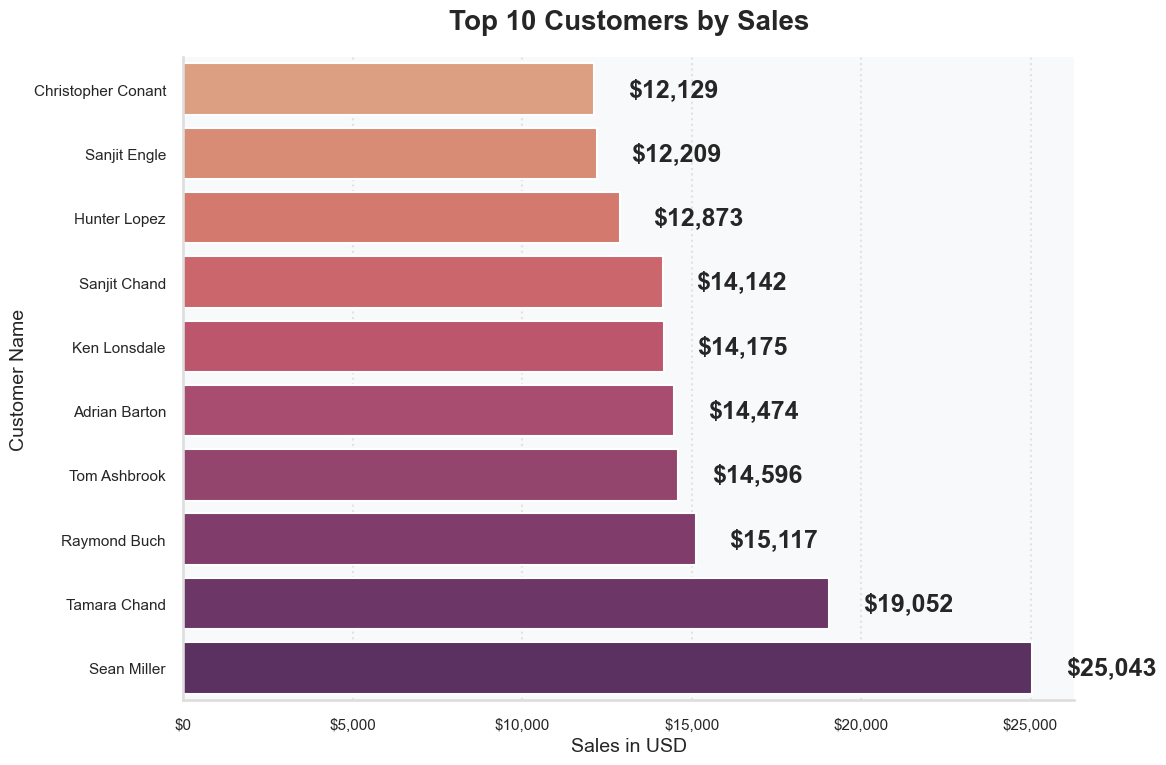

In [11]:
top_customers = customer_sales.head(10).sort_values("Sales")

plt.figure(figsize=(12,8))

ax = sns.barplot(
    data=top_customers,
    x="Sales",
    y="Customer Name",
    hue="Customer Name",
    palette="flare",
    legend=False
)

ax.set_title("Top 10 Customers by Sales", pad=20, weight="bold")
ax.set_xlabel("Sales in USD")
ax.set_ylabel("Customer Name")

ax.xaxis.set_major_formatter(FuncFormatter(lambda x, _: f"${x:,.0f}"))

for i, value in enumerate(top_customers["Sales"]):
    ax.text(value + 1000, i, f"${value:,.0f}", va="center", weight="bold")

sns.despine()
plt.tight_layout()
plt.show()

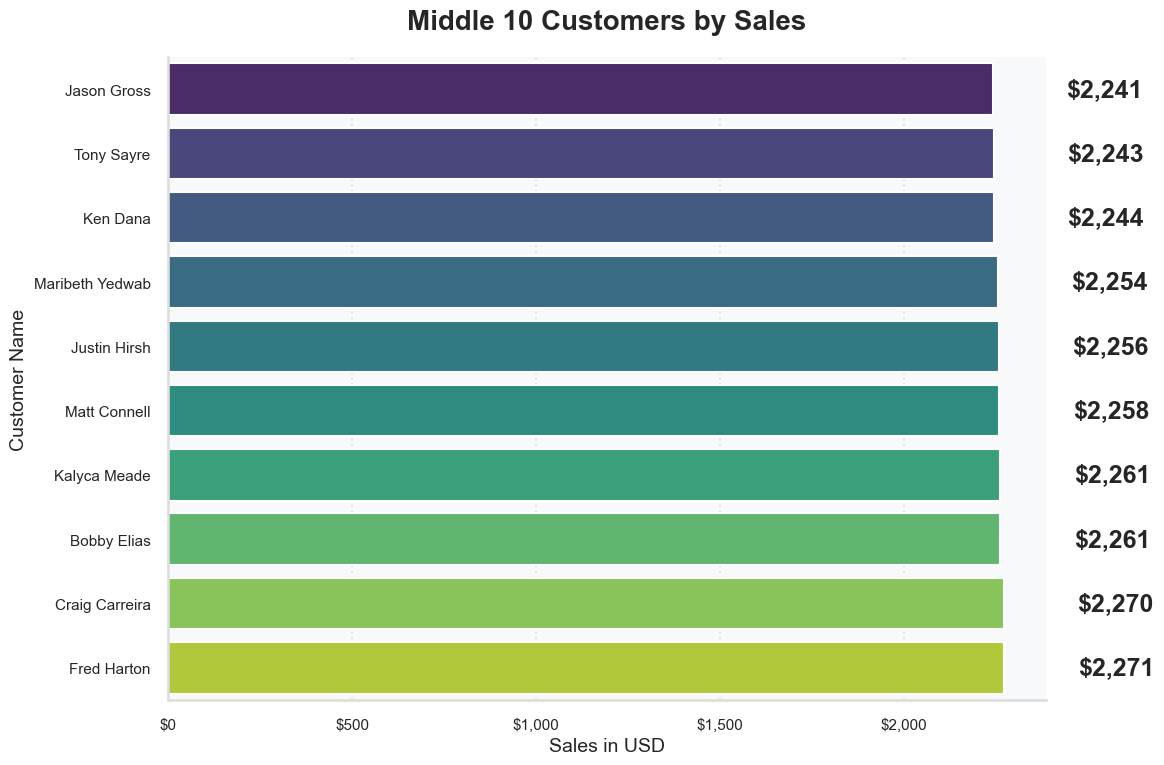

In [12]:
middle_index = len(customer_sales) // 2

middle_customers = (
    customer_sales.iloc[middle_index-5:middle_index+5]
    .sort_values("Sales")
)

plt.figure(figsize=(12,8))

ax = sns.barplot(
    data=middle_customers,
    x="Sales",
    y="Customer Name",
    hue="Customer Name",
    palette="viridis",
    legend=False
)

ax.set_title("Middle 10 Customers by Sales", pad=20, weight="bold")
ax.set_xlabel("Sales in USD")
ax.set_ylabel("Customer Name")

ax.xaxis.set_major_formatter(FuncFormatter(lambda x, _: f"${x:,.0f}"))

for i, value in enumerate(middle_customers["Sales"]):
    ax.text(value + 200, i, f"${value:,.0f}", va="center", weight="bold")

sns.despine()
plt.tight_layout()
plt.show()

/var/folders/l6/sc_t9j_s21525ws2zdhpngbr0000gn/T/ipykernel_25643/1562053662.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


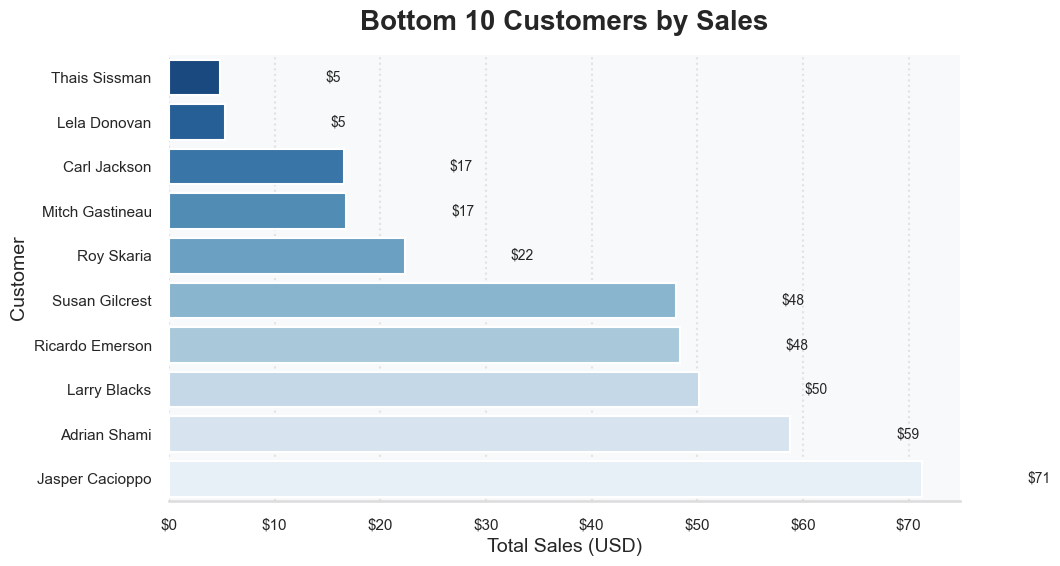

In [14]:
bottom_customers = (
    customer_sales.tail(10)
    .sort_values("Sales")
)

plt.figure(figsize=(11,6))

ax = sns.barplot(
    data=bottom_customers,
    x="Sales",
    y="Customer Name",
    palette="Blues_r"
)

ax.set_title("Bottom 10 Customers by Sales", pad=18, weight="bold")
ax.set_xlabel("Total Sales (USD)")
ax.set_ylabel("Customer")

ax.xaxis.set_major_formatter(FuncFormatter(lambda x, _: f"${x:,.0f}"))

# Add labels
for i, value in enumerate(bottom_customers["Sales"]):
    ax.text(
        value + 10,
        i,
        f"${value:,.0f}",
        va="center",
        fontsize=10
    )

sns.despine(left=True)
plt.tight_layout()
plt.show()

### Insight

The top ten customers contribute a disproportionately large share of total revenue, showing that a relatively small number of customers generate significant business value.

This concentration highlights the importance of maintaining strong relationships with high value customers.

However, heavy reliance on a small group of customers also introduces risk if those customers reduce spending or switch suppliers.

The company should prioritize retention strategies for its highest value customers while also expanding the broader customer base to reduce dependency on a limited group.

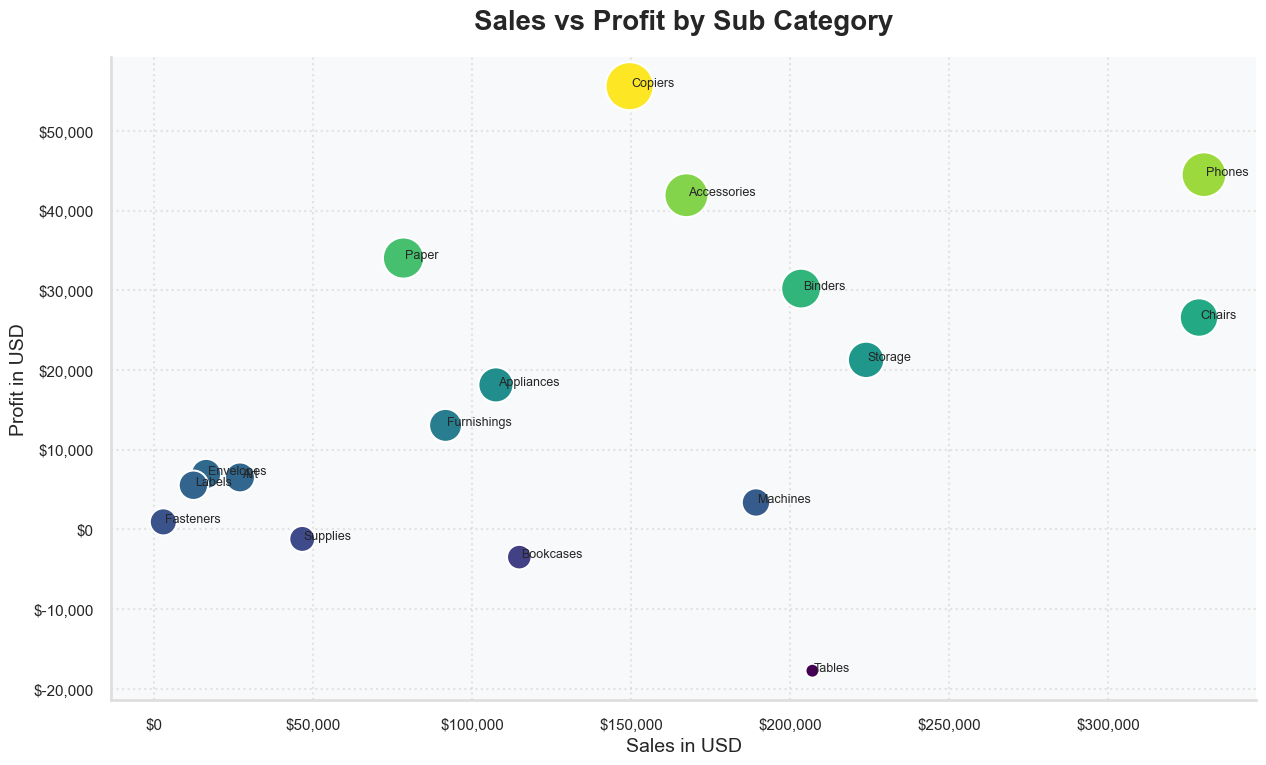

In [9]:
subcat_profit = (
    df.groupby("Sub-Category")[["Sales", "Profit"]]
    .sum()
    .reset_index()
)

plt.figure(figsize=(13, 8))
ax = sns.scatterplot(
    data=subcat_profit,
    x="Sales",
    y="Profit",
    size="Profit",
    hue="Profit",
    palette="viridis",
    sizes=(100, 1200),
    legend=False
)

for _, row in subcat_profit.iterrows():
    ax.text(row["Sales"] + 500, row["Profit"], row["Sub-Category"], fontsize=9)

ax.set_title("Sales vs Profit by Sub Category", pad=20, weight="bold")
ax.set_xlabel("Sales in USD")
ax.set_ylabel("Profit in USD")

ax.xaxis.set_major_formatter(FuncFormatter(lambda x, _: f"${x:,.0f}"))
ax.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f"${x:,.0f}"))

sns.despine()
plt.tight_layout()
plt.show()

### Insight

The comparison of sales and profit across sub categories reveals that not all high sales products generate equally strong profit.

Some sub categories perform well in both sales and profitability, making them key contributors to the overall health of the business.

Other sub categories generate high sales but comparatively lower profit, which may indicate higher costs, discounting pressure, or inefficient pricing.

This analysis helps identify which product groups truly drive value and which may require pricing adjustments, cost optimization, or product portfolio review.

## Final Business Recommendations

The analysis highlights several opportunities for improving business performance.

The company should study the factors behind the West region’s strong performance and explore whether similar strategies can be implemented in lower performing regions.

Technology products should remain a strategic focus due to their strong contribution to both revenue and profit.

Furniture products require further investigation to determine why profit performance is weaker despite strong sales.

Monthly demand patterns should be used to guide forecasting, marketing campaigns, and inventory planning.

Due to the fact that a relatively small group of customers drives a large share of revenue, the company should strengthen customer retention strategies while continuing to grow the overall customer base.